# CS610 Group 9: Hidden Linkage & Identity Resolution
**Focus:** SBERT Semantic Embeddings + GraphSAGE/GCN Link Prediction + POLE Network

---
### Import Dependencies
Importing deep learning frameworks, PyTorch Geometric for our GNNs, and `sentence-transformers` for our NLP Identity Resolution.

In [1]:
# !pip install torch torchvision torchaudio torch-geometric pandas networkx scikit-learn matplotlib sentence-transformers

import json
import ast
import torch
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sentence_transformers import SentenceTransformer
from torch_geometric.utils import from_networkx
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv, SAGEConv

# Set random seed for reproducibility
torch.manual_seed(42)

---
### Load Data & Generate SBERT Embeddings
We load the INTERPOL dataset (`targets.nested.json`). For each fugitive, we create a text profile and pass it through the **all-MiniLM-L6-v2 SBERT model** to generate a 384-dimensional dense semantic vector. This becomes the node feature (`x`) for our Graph Neural Networks.



In [2]:
records = []
with open('targets.nested.json', 'r') as f:
    for line in f:
        records.append(json.loads(line))
print(f"Loaded {len(records)} fugitives from JSON.")

print("Loading SBERT model (all-MiniLM-L6-v2)...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

node_features = {}
df_records = []

print("Generating SBERT embeddings for node features...")
for record in records:
    node_id = record.get('id')
    if not node_id: continue
        
    props = record.get('properties', {})
    name = record.get('caption', 'Unknown')
    topics = ", ".join(props.get('topics', []))
    birthplace = ", ".join(props.get('birthPlace', []))
    
    df_records.append({'id': node_id, 'name': name})
    text_profile = f"Name: {name}. Crime Topics: {topics}. Birthplace: {birthplace}."
    
    # Generate embedding and move to CPU (prevents Apple Silicon MPS crash)
    embedding = sbert_model.encode(text_profile, convert_to_tensor=True).cpu()
    node_features[node_id] = embedding

df_names = pd.DataFrame(df_records)
feature_dim = 384 
print("Node embeddings generated successfully!")

Loaded 6443 fugitives from JSON.
Loading SBERT model (all-MiniLM-L6-v2)...
Generating SBERT embeddings for node features...
Node embeddings generated successfully!


---
### Build the Rich Graph Structure
We construct the `NetworkX` graph. An edge (Hidden Linkage) is drawn between two fugitives only if they share **at least one country AND at least one crime topic**.



In [3]:
G = nx.Graph()

# Add Nodes with SBERT embeddings
for node_id, embedding in node_features.items():
    G.add_node(node_id, x=embedding)

# Add Edges based on shared Country AND shared Topic
for i in range(len(records)):
    for j in range(i + 1, len(records)):
        p1, p2 = records[i], records[j]
        id1, id2 = p1.get('id'), p2.get('id')
        if not id1 or not id2: continue
            
        props1, props2 = p1.get('properties', {}), p2.get('properties', {})
        c1, c2 = set(props1.get('country', [])), set(props2.get('country', []))
        t1, t2 = set(props1.get('topics', [])), set(props2.get('topics', []))
        
        if len(c1.intersection(c2)) > 0 and len(t1.intersection(t2)) > 0:
            G.add_edge(id1, id2)

print(f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph built with 6443 nodes and 4161634 edges.


---
### PyG Conversion & Data Splitting
Convert the graph to a **PyTorch Geometric (PyG)** Data object. We use `RandomLinkSplit` to hide 30% of the edges to evaluate our models' ability to predict them.

In [5]:
pyg_data = from_networkx(G)

transform = T.RandomLinkSplit(
    num_val=0.15, num_test=0.15, is_undirected=True, add_negative_train_samples=True
)
train_data, val_data, test_data = transform(pyg_data)
print("Data splits (Train: 70%, Val: 15%, Test: 15%) created successfully!")

Data splits (Train: 70%, Val: 15%, Test: 15%) created successfully!


---
### Define GCN and GraphSAGE Architectures
Both models will take our 384-dimensional SBERT text embeddings and pass them through graph convolution layers to predict the likelihood of hidden criminal linkages.



In [6]:
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def encode(self, x, edge_index): return self.conv2(self.conv1(x, edge_index).relu(), edge_index)
    def decode(self, z, edge_label_index): return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)
    def forward(self, x, edge_index, edge_label_index): return self.decode(self.encode(x, edge_index), edge_label_index)

class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
    def encode(self, x, edge_index): return self.conv2(self.conv1(x, edge_index).relu(), edge_index)
    def decode(self, z, edge_label_index): return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)
    def forward(self, x, edge_index, edge_label_index): return self.decode(self.encode(x, edge_index), edge_label_index)

gcn_model = GCNLinkPredictor(feature_dim, 128, 32)
sage_model = SAGELinkPredictor(feature_dim, 128, 32)
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=0.01)
optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

---
### Train & Evaluate (AUC, Recall, & Hits@K)
We evaluate our Link Prediction using the **AUC** metric (industry standard), **Recall** (to measure the proportion of true criminal linkages successfully identified above a 0.5 threshold), and **Hits@K** (measuring if true linkages rank higher than randomly generated false linkages). Progress is reported every 10 epochs.

In [8]:
from sklearn.metrics import roc_auc_score, recall_score

def train(model, optimizer, data):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_label_index)
    loss = criterion(out, data.edge_label.float())
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test_metrics(model, data, k_list=[10, 50, 100]):
    model.eval()
    out = model(data.x, data.edge_index, data.edge_label_index)
    preds = torch.sigmoid(out).cpu().numpy()
    targets = data.edge_label.cpu().numpy()
    
    # Calculate AUC and Recall
    auc = roc_auc_score(targets, preds)
    recall = recall_score(targets, (preds >= 0.5).astype(int))
    
    pos_preds = preds[targets == 1]
    neg_preds = preds[targets == 0]
    results = {'AUC': auc, 'Recall': recall}
    
    for k in k_list:
        hits = 0
        for pos_score in pos_preds:
            rank = (neg_preds > pos_score).sum() + 1
            if rank <= k: hits += 1
        results[f'Hits@{k}'] = hits / len(pos_preds) if len(pos_preds) > 0 else 0.0
    return results

print("--- Training GraphSAGE ---")
for epoch in range(1, 101):
    loss = train(sage_model, optimizer_sage, train_data)
    if epoch % 10 == 0:
        val_res = test_metrics(sage_model, val_data, k_list=[10, 50, 100])
        print(f"Epoch: {epoch:03d} | Train Loss: {loss:.4f} | Val AUC: {val_res['AUC']:.4f} | Val Recall: {val_res['Recall']:.4f} | \
        Hits@10: {val_res['Hits@10']:.4f} | Hits@50: {val_res['Hits@50']:.4f} | Hits@100: {val_res['Hits@100']:.4f}")

test_res_sage = test_metrics(sage_model, test_data, k_list=[10, 50, 100])
print(f"\nGraphSAGE Final Test -> AUC: {test_res_sage['AUC']:.4f} | Recall: {test_res_sage['Recall']:.4f} | \
Hits@10: {test_res_sage['Hits@10']:.4f} | Hits@50: {test_res_sage['Hits@50']:.4f} | Hits@100: {test_res_sage['Hits@100']:.4f}\n")

print("--- Training GCN ---")
for epoch in range(1, 101):
    loss = train(gcn_model, optimizer_gcn, train_data)
    if epoch % 10 == 0:
        val_res = test_metrics(gcn_model, val_data, k_list=[10, 50, 100])
        print(f"Epoch: {epoch:03d} | Train Loss: {loss:.4f} | Val AUC: {val_res['AUC']:.4f} | Val Recall: {val_res['Recall']:.4f} | \
        Hits@10: {val_res['Hits@10']:.4f} | Hits@50: {val_res['Hits@50']:.4f} | Hits@100: {val_res['Hits@100']:.4f}")

test_res_gcn = test_metrics(gcn_model, test_data, k_list=[10, 50, 100])
print(f"\nGCN Final Test       -> AUC: {test_res_gcn['AUC']:.4f} | Recall: {test_res_gcn['Recall']:.4f} | Hits@10: {test_res_gcn['Hits@10']:.4f} | \
Hits@50: {test_res_gcn['Hits@50']:.4f} | Hits@100: {test_res_gcn['Hits@100']:.4f}")

--- Training GraphSAGE ---
Epoch: 010 | Train Loss: 0.1882 | Val AUC: 0.9980 | Val Recall: 1.0000 | Hits@10: 0.9082 | Hits@50: 0.9082 | Hits@100: 0.9082
Epoch: 020 | Train Loss: 0.1750 | Val AUC: 0.9985 | Val Recall: 1.0000 | Hits@10: 0.9082 | Hits@50: 0.9082 | Hits@100: 0.9277
Epoch: 030 | Train Loss: 0.1689 | Val AUC: 0.9983 | Val Recall: 1.0000 | Hits@10: 0.9286 | Hits@50: 0.9448 | Hits@100: 0.9532
Epoch: 040 | Train Loss: 0.1631 | Val AUC: 0.9982 | Val Recall: 1.0000 | Hits@10: 0.9407 | Hits@50: 0.9567 | Hits@100: 0.9643
Epoch: 050 | Train Loss: 0.1573 | Val AUC: 0.9980 | Val Recall: 1.0000 | Hits@10: 0.9491 | Hits@50: 0.9652 | Hits@100: 0.9697
Epoch: 060 | Train Loss: 0.1523 | Val AUC: 0.9978 | Val Recall: 1.0000 | Hits@10: 0.9578 | Hits@50: 0.9709 | Hits@100: 0.9732
Epoch: 070 | Train Loss: 0.1478 | Val AUC: 0.9975 | Val Recall: 1.0000 | Hits@10: 0.9668 | Hits@50: 0.9740 | Hits@100: 0.9745
Epoch: 080 | Train Loss: 0.1438 | Val AUC: 0.9973 | Val Recall: 0.9999 | Hits@10: 0.9719 | 

---
### Ego-Graph Visualization Tool
This function isolates a single fugitive and plots a "Spider Web" of their immediate hidden connections.



Plotting 52 hidden connections for SANAVBARI NIKITENKO...


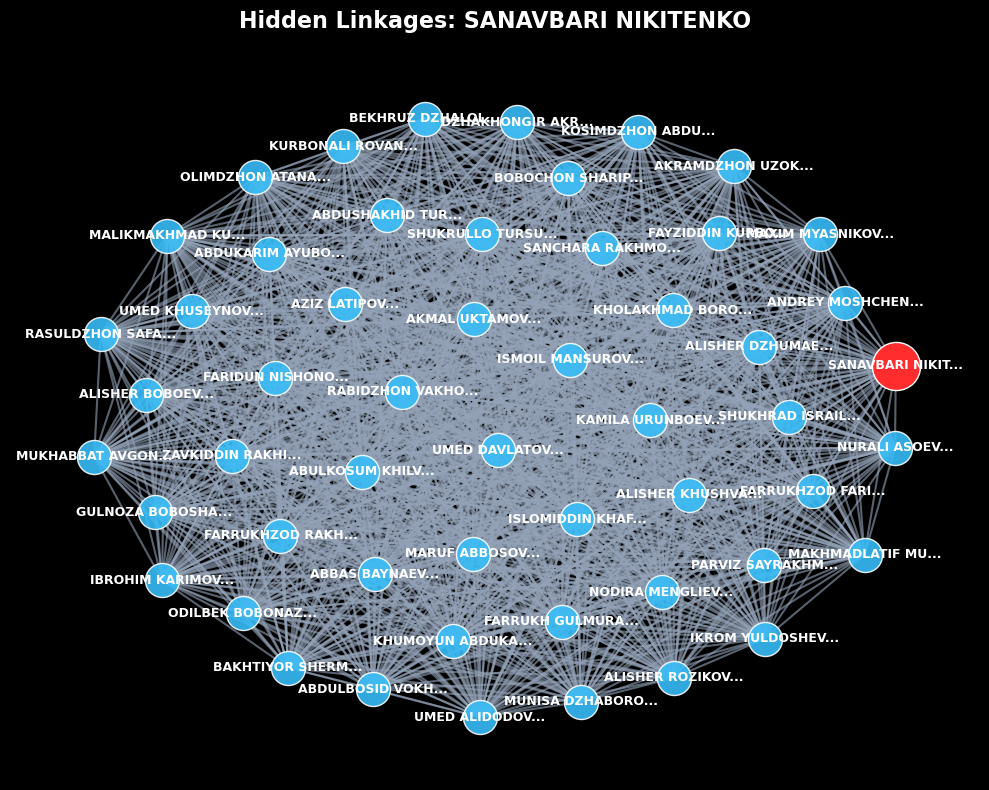

In [9]:
def plot_fugitive_network(query, df, G_net, radius=1):
    target_id, target_name = None, None
    
    if query in df['id'].values:
        target_id = query
        target_name = df[df['id'] == query]['name'].iloc[0]
    else:
        matches = df[df['name'].str.contains(query, case=False, na=False)]
        if matches.empty: return print(f"X No fugitive found matching: '{query}'")
        target_id, target_name = matches.iloc[0]['id'], matches.iloc[0]['name']
        
    if target_id not in G_net.nodes(): return print(f"WARNING: {target_name} has no hidden linkages (Isolated).")
        
    subgraph = nx.ego_graph(G_net, target_id, radius=radius)
    if subgraph.number_of_nodes() <= 1: return print(f"WARNING: {target_name} is in the graph but currently has no shared connections.")
    
    print(f"Plotting {subgraph.number_of_nodes() - 1} hidden connections for {target_name}...")
    plt.style.use('dark_background')
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subgraph, seed=42, k=0.5)
    
    neighbors = [n for n in subgraph.nodes() if n != target_id]
    nx.draw_networkx_nodes(subgraph, pos, nodelist=neighbors, node_color='#38bdf8', node_size=600, edgecolors='white', alpha=0.9)
    nx.draw_networkx_nodes(subgraph, pos, nodelist=[target_id], node_color='#ff2d2d', node_size=1200, edgecolors='white')
    nx.draw_networkx_edges(subgraph, pos, alpha=0.6, edge_color='#94a3b8', width=1.5)
    
    id_to_name = dict(zip(df['id'], df['name']))
    labels = {n: id_to_name.get(n, str(n))[:15] + "..." for n in subgraph.nodes()}
    
    nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=9, font_weight='bold', font_color='white')
    plt.title(f"Hidden Linkages: {target_name}", fontsize=16, fontweight='bold', color='white', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run a test visualization
plot_fugitive_network("SANAVBARI NIKITENKO", df_names, G)

---
### POLE Framework Network Analysis
Using the **POLE (Persons, Objects, Locations, Events)** framework, we parse the NER entities generated by the pipeline to turn flat rows into a dense intelligence web. 

**Legend Mapping:**
* **Persons:** Red (`PERSON`)
* **Objects:** Yellow (`ORG` / Assests)
* **Locations:** Teal (`GPE`)
* **Events:** Grey (`CASE` / Incidents)

This visualizes how different entities intersect across multiple fugitive case files.



Rows with entities for POLE processing: 1,360 / 7,023
POLE Graph: 2,502 nodes, 2,586 edges
Removed 59 hub nodes (degree > 5)


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


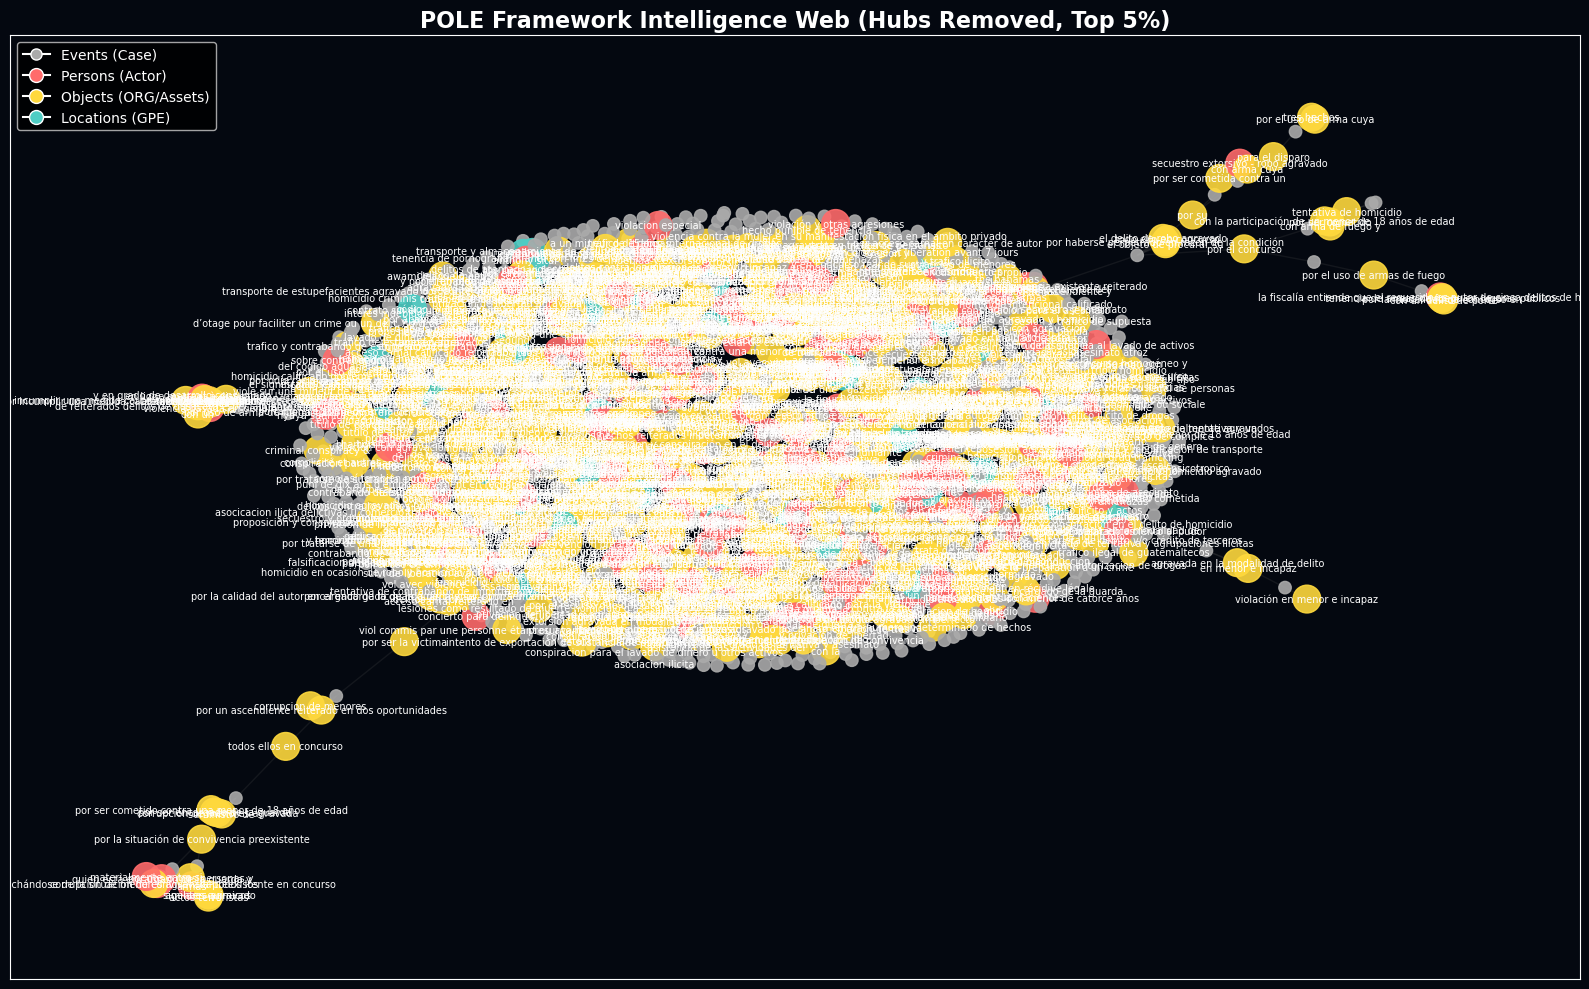


POLE Centrality Analysis — Top 10 Key Entities:
  [Object  ] trafico ilicito                0.0020
  [Location] iraq                           0.0020
  [Object  ] asesinato                      0.0020
  [Object  ] commis en bande                0.0020
  [Object  ] trata de personas              0.0020
  [Object  ] por el uso de arma de fuego en concurso 0.0020
  [Person  ] secuestro extorsivo            0.0020
  [Object  ] infracción                     0.0020
  [Object  ] concours en bande organisée    0.0020
  [Person  ] la situación de convivencia    0.0020

POLE Entity Breakdown:
  Object   (ORG   ) : 820 nodes
  Person   (PERSON) : 212 nodes
  Location (GPE   ) : 51 nodes


In [10]:
# Load the dataset with extracted entities
try:
    df_ready = pd.read_csv('crime_analysis_results_aft_transformer_ner.csv')
except FileNotFoundError:
    print("WARNING: Please ensure 'crime_analysis_results_aft_transformer_ner.csv' is in your directory to run POLE.")
    df_ready = pd.DataFrame({'entities': []}) # Fallback empty DF

def safe_parse(val):
    if isinstance(val, list): return val
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

if not df_ready.empty and 'entities' in df_ready.columns:
    df_ready['entities'] = df_ready['entities'].apply(safe_parse)
    df_network = df_ready[df_ready['entities'].apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()
    print(f"Rows with entities for POLE processing: {len(df_network):,} / {len(df_ready):,}")

    # Build POLE Graph
    G_pole = nx.Graph()
    POLE_COLORS = {"PERSON": "#FF6B6B", "ORG": "#FFD93D", "GPE": "#4ECDC4", "CASE": "#AAAAAA"}
    skipped = 0

    for idx, row in df_network.iterrows():
        case_node = f"Event_Case_{idx}"
        G_pole.add_node(case_node, node_type="CASE")

        for entity in row['entities']:
            if isinstance(entity, tuple) and len(entity) == 2:
                ent_text, ent_label = entity[0].strip(), entity[1]
            elif isinstance(entity, str):
                ent_text, ent_label = entity.strip(), "UNKNOWN"
            else:
                skipped += 1
                continue

            if not ent_text:
                skipped += 1
                continue

            G_pole.add_node(ent_text, node_type=ent_label)
            G_pole.add_edge(case_node, ent_text)

    print(f"POLE Graph: {G_pole.number_of_nodes():,} nodes, {G_pole.number_of_edges():,} edges")

    # Prune Hubs
    def prune_hub_nodes(G, percentile=95):
        if G.number_of_nodes() == 0: return G
        degrees = dict(G.degree())
        deg_vals = list(degrees.values())
        threshold = np.percentile(deg_vals, percentile)
        hubs_to_remove = [n for n, deg in degrees.items() if deg > threshold and not str(n).startswith("Event_Case_")]
        
        G_cleaned = G.copy()
        G_cleaned.remove_nodes_from(hubs_to_remove)
        print(f"Removed {len(hubs_to_remove)} hub nodes (degree > {threshold:.0f})")
        return G_cleaned

    G_simple = prune_hub_nodes(G_pole, percentile=95)

    # Node Styling for POLE Framework
    colors, sizes = [], []
    for n in G_simple.nodes():
        ntype = G_simple.nodes[n].get('node_type', 'UNKNOWN')
        if ntype == "CASE":
            colors.append("#AAAAAA")
            sizes.append(80)
        else:
            colors.append(POLE_COLORS.get(ntype, "#CCCCCC"))
            sizes.append(400)

    # Plotting
    fig, ax = plt.subplots(figsize=(16, 10))
    pos = nx.spring_layout(G_simple, k=1.2, seed=42)
    
    nx.draw_networkx_edges(G_simple, pos, ax=ax, alpha=0.2, edge_color="#555555")
    nx.draw_networkx_nodes(G_simple, pos, ax=ax, node_color=colors, node_size=sizes, alpha=0.9)

    entity_nodes = {n: n for n in G_simple.nodes() if not str(n).startswith("Event_Case_")}
    nx.draw_networkx_labels(G_simple, pos, labels=entity_nodes, ax=ax, font_size=7, font_color="white")

    ax.set_title("POLE Framework Intelligence Web (Hubs Removed, Top 5%)", fontsize=16, fontweight='bold', color='white')
    
    # POLE Specific Legend
    legend_elements = [
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#AAAAAA', markersize=8, label='Events (Case)'), 
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#FF6B6B', markersize=10, label='Persons (Actor)'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#FFD93D', markersize=10, label='Objects (ORG/Assets)'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#4ECDC4', markersize=10, label='Locations (GPE)')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    fig.patch.set_facecolor('#040810')
    ax.set_facecolor('#040810')
    plt.tight_layout()
    plt.show()

    # Degree Centrality Analysis
    print("\nPOLE Centrality Analysis — Top 10 Key Entities:")
    centrality = nx.degree_centrality(G_simple)
    top_degree = sorted([(n, s) for n, s in centrality.items() if not str(n).startswith("Event_Case_")], key=lambda x: x[1], reverse=True)[:10]
    for node, score in top_degree:
        ntype = G_simple.nodes[node].get('node_type', '?')
        pole_type = "Object" if ntype == "ORG" else "Location" if ntype == "GPE" else "Person" if ntype == "PERSON" else "Unknown"
        print(f"  [{pole_type:<8}] {node:<30} {score:.4f}")

    # Breakdown
    print("\nPOLE Entity Breakdown:")
    type_counts = Counter(data.get('node_type', 'UNKNOWN') for n, data in G_simple.nodes(data=True) if not str(n).startswith("Event_Case_"))
    for etype, count in type_counts.most_common():
        pole_type = "Object" if etype == "ORG" else "Location" if etype == "GPE" else "Person" if etype == "PERSON" else "Unknown"
        print(f"  {pole_type:<8} ({etype:<6}) : {count:,} nodes")
